In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Data Gathering - Kaggle
# It consists of 10,000 rows and 10 columns...
data = pd.read_csv('college_student_placement_dataset.csv')

In [ ]:
data.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [ ]:
# Domain Knowledge
# The data is about college placements... it's a classification problem.
# IQ -> 1-100
# Prev_Sem_Result -> GPA
# CGPA -> cumulative GPA
# Academic_Performance -> 1-10
# Iternship_Experience -> Yes/No
# Extra_Curricular_Score -> 1-10
# Communication_Skilla -> 1-10
# Projects_Completed -> 1-5
# Placement(Target Variable or output column) -> Yes/No

<Axes: xlabel='IQ', ylabel='Count'>

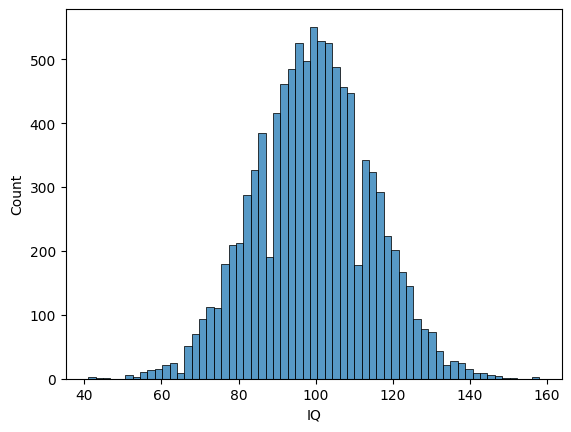

In [ ]:
sns.histplot(data['IQ'])
# It shows that the data is distributed normally... (Bell shaped distribution)

<Axes: xlabel='Prev_Sem_Result', ylabel='Count'>

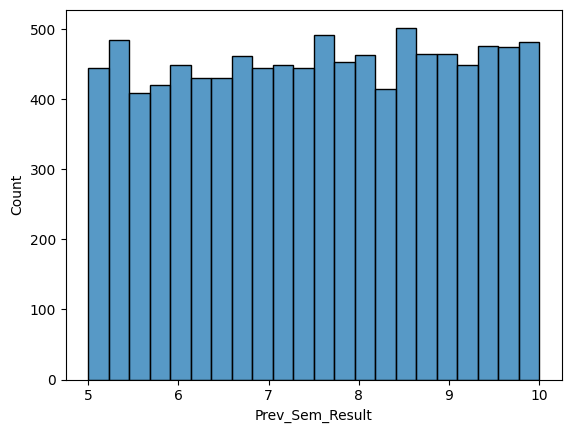

In [ ]:
sns.histplot(data['Prev_Sem_Result'])
# The values ranges between 5 and 10

Minimum value is: 4.54
Maximum value is: 10.46
0


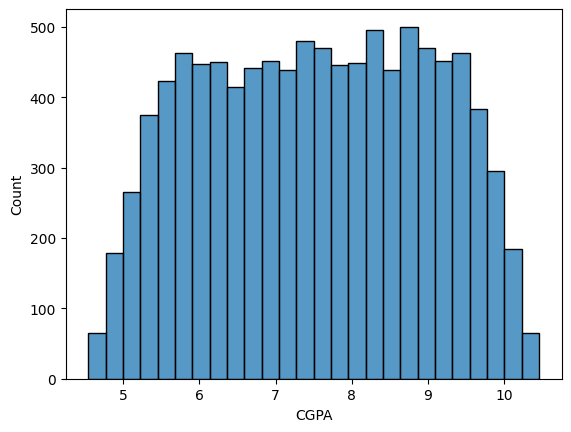

In [ ]:
sns.histplot(data['CGPA'])
print(f"Minimum value is: {min(data['CGPA'])}")
print(f"Maximum value is: {max(data['CGPA'])}")
# There are 249 rows which has incorrect vlues, where CGPA > 10. lets clip the values
# clip() cuts off values that go beyond a limit and replaces them with the limit itself.
# Justification: if we notice Prev_Sem_Result the values it ranges from 9.80 t0 9.90 so it is appropriate.
data["CGPA"] = data["CGPA"].clip(upper=10)
print(len(data[data['CGPA'] > 10]))


In [ ]:
data.sort_values(by="Prev_Sem_Result", ascending=False)

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
9165,CLG0043,99,10.0,10.00,3,No,3,9,2,Yes
2477,CLG0041,121,10.0,9.69,5,No,6,3,5,Yes
2950,CLG0004,118,10.0,9.96,10,Yes,9,5,2,Yes
2302,CLG0004,94,10.0,9.75,2,No,10,5,3,No
6844,CLG0068,136,10.0,10.00,8,Yes,2,1,1,No
...,...,...,...,...,...,...,...,...,...,...
3892,CLG0004,88,5.0,4.69,3,No,0,2,0,No
9264,CLG0069,86,5.0,4.72,7,Yes,10,6,0,No
3333,CLG0038,108,5.0,4.70,6,No,8,7,3,No
2602,CLG0088,90,5.0,4.81,7,No,3,6,4,No


<Axes: xlabel='Academic_Performance', ylabel='Count'>

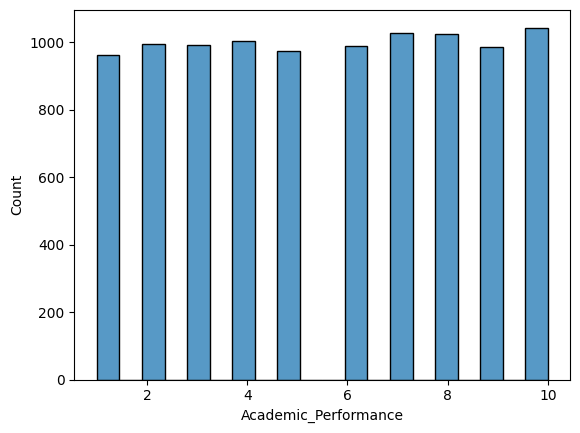

In [ ]:
sns.histplot(data['Academic_Performance'])

<Axes: xlabel='Internship_Experience', ylabel='count'>

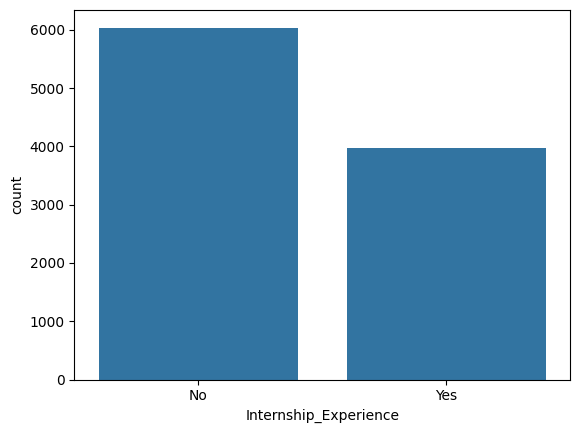

In [ ]:
sns.countplot(x=data['Internship_Experience'])

<Axes: xlabel='Communication_Skills', ylabel='Count'>

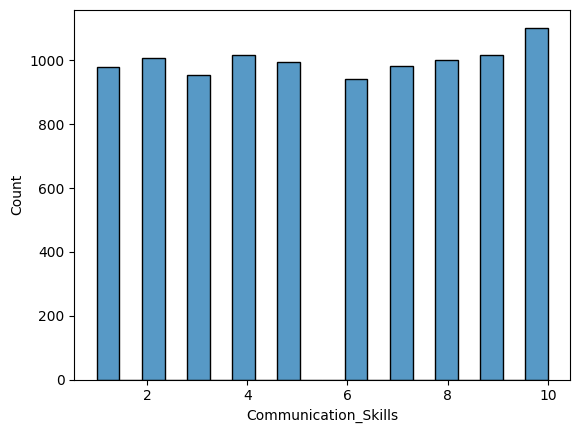

In [ ]:
sns.histplot(data['Communication_Skills'])

<Axes: xlabel='Projects_Completed', ylabel='Count'>

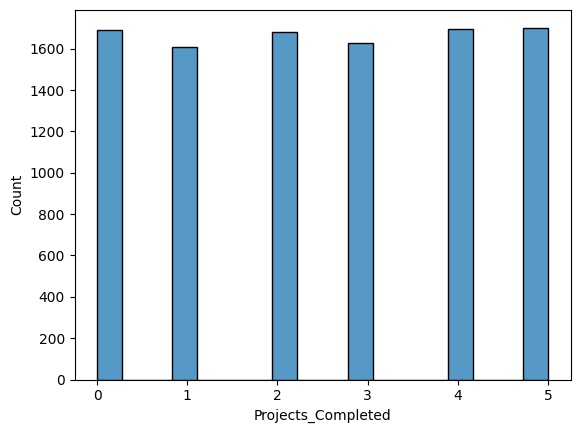

In [ ]:
sns.histplot(data['Projects_Completed'])

<Axes: >

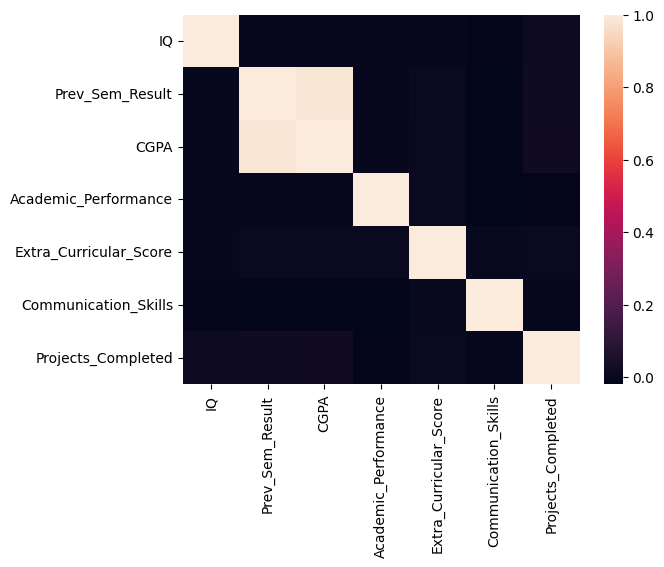

In [ ]:
# Let's Idetify the correlation between the columns by using corr() fucntion
sns.heatmap(data.drop(['College_ID','Internship_Experience','Placement'],axis=1).corr())

👆 This dark map indicates that the model has different independent features which is an advantage where model can predict the output value by considering different perspectives independently.

In [ ]:
data[['CGPA','Prev_Sem_Result']].corr()

,CGPA,Prev_Sem_Result
CGPA,1.000000,0.981089
Prev_Sem_Result,0.981089,1.000000


In [ ]:
data.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [ ]:
# Checking duplicates
data.duplicated().sum()

np.int64(0)

In [ ]:
# Checking null values
data.isnull().sum().sum()

np.int64(0)

In [ ]:
data.shape

(10000, 10)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Placement'] = le.fit_transform(data['Placement'])
data['Internship_Experience'] = le.fit_transform(data['Internship_Experience'])

In [ ]:
data.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,0,8,8,4,0
1,CLG0061,97,5.52,5.37,8,0,7,8,0,0
2,CLG0036,109,5.36,5.83,9,0,3,1,1,0
3,CLG0055,122,5.47,5.75,6,1,1,6,1,0
4,CLG0004,96,7.91,7.69,7,0,8,10,2,0


In [ ]:
data.info()
# Now columns "Internship_Experience" and "Placement" are converted into '0'and '1'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  int64  
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 781.4+ KB


In [ ]:
# Data Preprocessing

In [ ]:
data['Placement'].value_counts()
# Data is not balanced

,count
Placement,
0,8341
1,1659


In [ ]:
data = data.drop(columns=['College_ID'])

In [ ]:
data.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,0,8,8,4,0
1,97,5.52,5.37,8,0,7,8,0,0
2,109,5.36,5.83,9,0,3,1,1,0
3,122,5.47,5.75,6,1,1,6,1,0
4,96,7.91,7.69,7,0,8,10,2,0


In [ ]:
x = data.drop(['Placement','Prev_Sem_Result'], axis=1)
# We removed Prev_Sem_Result because there is much correlation between 'CGPA' and 'Prev_Sem_Result'
y = data['Placement']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state = 98, train_size=0.8 )

In [ ]:
# Data Transformation
# different features have different range of valules so scaling is required.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)



In [ ]:
feature_names = x.columns.tolist()


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_sampled,y_train_sampled = smote.fit_resample(x_train,y_train)

In [ ]:
pd.Series(y_train).value_counts()

,count
Placement,
0,6683
1,1317


## **LogisticRegression**

In [ ]:
from sklearn.linear_model import LogisticRegression

modelLR = LogisticRegression(max_iter=1000)
modelLR.fit(x_train_sampled, y_train_sampled)


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = modelLR.predict(x_test)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.85      0.91      1658
           1       0.55      0.87      0.67       342

    accuracy                           0.86      2000
   macro avg       0.76      0.86      0.79      2000
weighted avg       0.90      0.86      0.87      2000



## **DecisionTreeClassifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
modelDT = DecisionTreeClassifier()

In [ ]:
modelDT.fit(x_train_sampled,y_train_sampled)

DecisionTreeClassifier()

In [ ]:
y_pred = modelDT.predict(x_test)

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1658
           1       0.99      1.00      1.00       342

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



## **RandomForest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
modelRF = RandomForestClassifier()

In [ ]:
modelRF.fit(x_train_sampled,y_train_sampled)

RandomForestClassifier()

In [ ]:
y_pred = modelRF.predict(x_test)

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1658
           1       1.00      1.00      1.00       342

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



## **XGBostClassifier**

In [ ]:
from xgboost import XGBClassifier
modelXG = XGBClassifier(objective="binary:logistic",
    eval_metric="logloss",
    random_state=42)

In [ ]:
modelXG.fit(x_train_sampled,y_train_sampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred =modelXG.predict(x_test)

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1658
           1       1.00      1.00      1.00       342

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1658    0]
 [   0  342]]


## **NaiveBayes(GaussianNB)**

In [ ]:
from sklearn.naive_bayes import GaussianNB
modelNB = GaussianNB()
modelNB.fit(x_train,y_train)

GaussianNB()

In [ ]:
y_pred = modelNB.predict(x_test)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      1658
           1       0.91      0.46      0.61       342

    accuracy                           0.90      2000
   macro avg       0.90      0.73      0.78      2000
weighted avg       0.90      0.90      0.89      2000



## **SupportVectorMachines**

In [ ]:
from sklearn.svm import SVC
modelSVM = SVC(kernel='linear', class_weight='balanced')

In [ ]:
modelSVM.fit(x_train,y_train)

SVC(class_weight='balanced', kernel='linear')

In [ ]:
y_pred = modelSVM.predict(x_test)

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.84      0.90      1658
           1       0.53      0.88      0.66       342

    accuracy                           0.85      2000
   macro avg       0.75      0.86      0.78      2000
weighted avg       0.90      0.85      0.86      2000



In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1393  265]
 [  41  301]]


In [ ]:
import pickle

pickle.dump(modelXG,open("modelXG.pkl","wb"))

In [ ]:
pickle.dump(scaler, open("scaler.pkl", "wb"))


In [ ]:
import gradio as gr
import pickle
import numpy as np
import random

model = pickle.load(open("modelXG.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

def predict_placement(
    iq, cgpa, academic_performance, internship_experience,
    extra_curricular_score, communication_skills, projects_completed
):
    input_data = np.array([[
        iq, cgpa, academic_performance, internship_experience,
        extra_curricular_score, communication_skills, projects_completed
    ]])

    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)[0]

    if prediction == 1:
        return "# **PLACED** 🎉"
    else:
        return "# **NOT PLACED** ❌"

def autofill_random():
    return (
        random.randint(60, 120),
        round(random.uniform(5.0, 9.5), 2),
        random.randint(4, 9),
        random.choice([0, 1]),
        random.randint(3, 9),
        random.randint(4, 9),
        random.randint(1, 5)
    )

with gr.Blocks(title="Placement Predictor") as app:

    gr.Markdown("# 🎓 Placement Predictor")

    with gr.Row():
        with gr.Column(scale=3):
            gr.Markdown("### 📝 Inputs")
            iq = gr.Number(label="IQ", value=75)
            cgpa = gr.Number(label="CGPA", value=7.5)
            academic_performance = gr.Slider(1, 10, value=7, step=1, label="Academic Performance")
            internship_experience = gr.Radio([0, 1], label="Internship (0 = No, 1 = Yes)", value=1)
            extra_curricular_score = gr.Slider(1, 10, value=6, step=1, label="Extra Curricular Score")
            communication_skills = gr.Slider(1, 10, value=7, step=1, label="Communication Skills")
            projects_completed = gr.Slider(1, 5, value=2, step=1, label="Projects Completed")

        with gr.Column(scale=1):
            gr.Markdown("### 🎯 Output")
            output = gr.Markdown("# **Click Predict**")

            gr.Image(value="image.png", show_label=False)

    with gr.Row():
        predict_btn = gr.Button("🔍 Predict", variant="primary")
        random_btn = gr.Button("🎲 Auto-Fill", variant="secondary")

    predict_btn.click(
        predict_placement,
        inputs=[
            iq,
            cgpa,
            academic_performance,
            internship_experience,
            extra_curricular_score,
            communication_skills,
            projects_completed
        ],
        outputs=output
    )

    random_btn.click(
        autofill_random,
        outputs=[
            iq,
            cgpa,
            academic_performance,
            internship_experience,
            extra_curricular_score,
            communication_skills,
            projects_completed
        ]
    )

app.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a4d47a98f755ddd8c8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
data = {
    "names": ['Yethish','kiran','suresh','pandu']
}